# Complementary Macroeconomics

## 10th Session

# RBC Model Simulation, VAR & Impulse Responses.ipynb

# Introduction to a Special Case of the RBC Model

This notebook explores a streamlined version of the Real Business Cycle (RBC) model, inspired by David Romer's *Advanced Macroeconomics*, Chapter 5: **Real-Business-Cycle Theory**. By removing government intervention and assuming full capital depreciation each period, we isolate the core dynamics of consumption, labor supply, and production in a frictionless economy.

This simplification enables us to derive closed-form analytical solutions and simulate the model’s behavior using Python. We focus on:

- The evolution of technology shocks
- The behavior of output, investment, and wages
- The structure and implications of the value function

We begin by laying out the model’s equations and assumptions, then solve for key relationships using Bellman’s Equation and a log-linear guess for the value function. Finally, we simulate impulse response functions (IRFs) to visualize how technology shocks propagate through the economy.


## The RBC Model Framework

The RBC model, under these assumptions, is defined by the following key equations:

1. **Production Function**: 

   $Y_t = K_t^{\alpha} (A_t L_t)^{1-\alpha}$

2. **Capital Accumulation**: 

   $K_{t+1} = Y_t - C_t$ 

3. **Technology Dynamics**: 
   
    $\ln A_t = \bar A + gt + \tilde A_t$

   $\tilde A_t = \rho_A \tilde A_{t+1} + \varepsilon_{A,t}$


4. **Labor Supply Dynamics**: 
   
    $\ln N_t = \bar N + nt$

5. **Utility Function**: 
   
    $u_t = \ln c_t + b \ln (1 - ell_t)$

To simplify our analysis, we set $n = g = \bar A = \bar N = 0$. Consequently, population is normalized to one, leading to:

$\ln N_t = 0 \rightarrow N_t = 1$

This adjustment allows us to equate labor supply per person, $ell_t$, to total labor supply. The production function then transforms to:

$Y_t = K_{t}^{\alpha}[A_t ell_t]^{1-\alpha}$

### Technology Adjustments

With $g$ and $\bar{A}$ set to zero, the technology equation simplifies to:

$
\ln A_t = \tilde{A}_t \Rightarrow \ln A_t = \rho_A \ln A_{t-1} + \varepsilon_{A,t}
$

## Value Function and Optimization

### Defining the Value Function

At time $t$, the value function can be expressed as:

$
V_t = \max E_t \left[ \sum_{s=t}^{\infty} e^{-\rho (s-t)} \left( \ln C_s + b \ln(1 - l_s) \right) \right]
$

This value function represents the expected present value of lifetime utility, subject to the constraints imposed by the production function, capital accumulation, and technology dynamics.

### Bellman's Equation

The relationship between the value function and current choices can be captured by Bellman's Equation:

$
V_t(K_t, A_t) = \max_{C_t, \ell_t} \left[ \ln C_t + b \ln(1 - \ell_t) + e^{-\rho} E_t \left[ V_{t+1}(K_{t+1}, A_{t+1}) \right] \right]
$

This equation emphasizes that the current value function is determined by today's utility plus the expected future value, appropriately discounted.

### Guessing the Value Function Form

We hypothesize that the value function takes a log-linear form:

$
V(K_t, A_t) = \beta_0 + \beta_K \ln K_t + \beta_A \ln A_t
$

Substituting this guess into Bellman's Equation provides a pathway to derive the optimal consumption and labor supply decisions.

## Deriving Key Relationships

### Consumption and Output Ratio

Through optimization, we find the ratio of consumption to output:

$
\frac{C_t}{Y_t} = \frac{1}{1 + e^{-\rho} \beta_K}
$

This ratio remains independent of capital \(K_t\) and technology \(A_t\).

### Labor Supply Dynamics

The optimal labor supply per person is derived as:

$
\ell_t = \frac{(1 - \alpha)(1 + e^{-\rho} \beta_K)}{(1 - \alpha)(1 + e^{-\rho} \beta_K) + b}
$

This expression illustrates that labor supply is also independent of $K_t$ and $A_t$

## Impulse Response Functions (IRFs)

To understand how technology shocks propagate through the economy, we simulate impulse response functions (IRFs) using a Vector Autoregression (VAR) model. This approach allows us to trace the dynamic effects of a one-time shock to technology on key macroeconomic variables over time.

### Steps in the IRF Analysis

1. **Simulate the Economy**  
   We generate time series data for output, consumption, investment, wages, and the value function by solving the RBC model forward over 50 periods. Technology evolves stochastically via an AR(1) process:
   $
   \ln A_t = \rho_A \ln A_{t-1} + \varepsilon_{A,t}
   $
   where $\varepsilon_{A,t}$ is a normally distributed shock.

2. **Construct the VAR Dataset**  
   We log-transform the relevant variables and stack them into a matrix:
   - Technology $\ln A_t$
   - Output $\ln Y_t$
   - Consumption $\ln C_t$
   - Real Wage $\ln w_t$
   - Investment $\ln I_t$
   - Value Function $V_t$

3. **Estimate the VAR Model**  
   Using statsmodels, we fit a VAR with two lags to capture the interdependencies among variables.

4. **Generate IRFs**  
   We compute the IRFs over 40 periods to visualize how a one-time positive shock to technology affects each variable. These plots show the dynamic adjustment paths and help us interpret the transmission mechanism of productivity shocks.




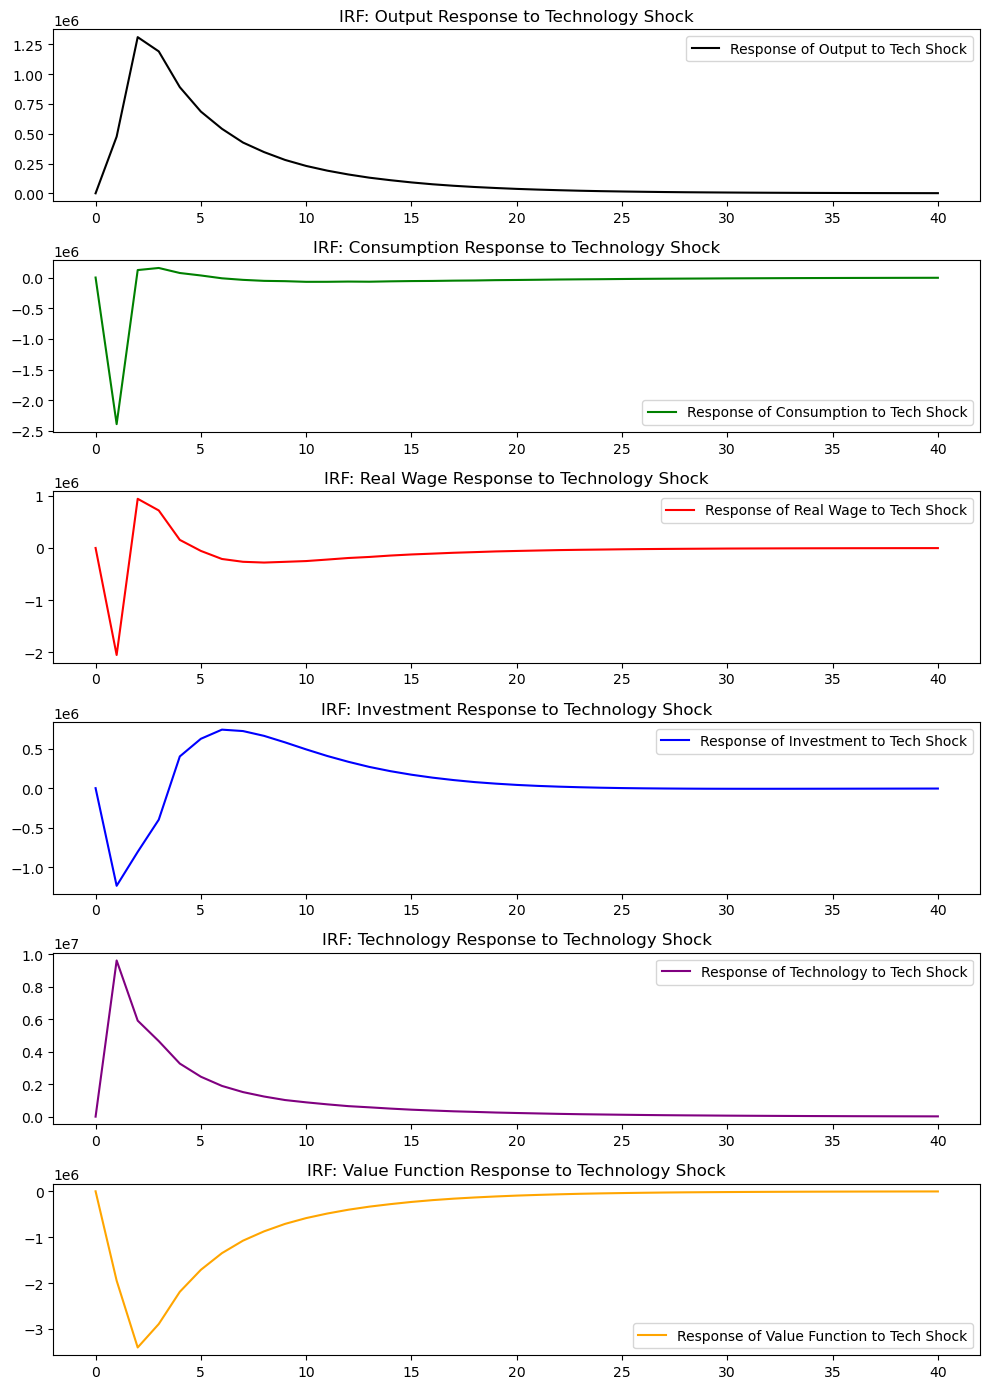

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(42)

# Parameters
n = 0
g = 0
rho_A = 0.9
sigma_eps = 0.02
alpha = 1/3
rho = 0.03
beta_0 = 0.05
b = 2

T = 50
T_irf = 40

ell_t = (1 - alpha) / ((1 - alpha) + b * (1 - alpha * np.exp(-rho)))
beta_A = (1 - alpha) / (1 - alpha * np.exp(-rho) * (1 - rho_A * np.exp(-rho)))
beta_K = alpha / (1 - alpha * np.exp(-rho))

Y_t = np.zeros(T)
ln_Y_t = np.zeros(T)
ln_A_t = np.zeros(T)
epsilon = np.random.normal(0, sigma_eps, T)

K_t = np.zeros(T)
ln_K_t = np.zeros(T)

C_t = np.zeros(T)
ln_C_t = np.zeros(T)

I_t = np.zeros(T)
w_t = np.zeros(T)

#Initial values
K_t[0] = 0.43
ln_K_t[0] = np.log(K_t[0])
ln_A_t[0] = 0

ln_Y_t[0] = alpha * ln_K_t[0] + (1 - alpha) * ln_A_t[0] +  (1 - alpha) * np.log(ell_t)
Y_t[0] = np.exp(ln_Y_t[0])

ln_C_t[0] = -np.log(1 + np.exp(-rho) * beta_K) + ln_Y_t[0]
C_t[0] = np.exp(ln_C_t[0])

I_t[0] = Y_t[0] - C_t[0]
w_t[0] = (1 - alpha) * (Y_t[0] / ell_t)

for t in range(1, T):
    ln_A_t[t] = rho_A * ln_A_t[t-1] + epsilon[t]
    ln_Y_t[t] = alpha * ln_K_t[t-1] + (1 - alpha) * ln_A_t[t] + (1 - alpha) * np.log(ell_t)
    Y_t[t] = np.exp(ln_Y_t[t])
    ln_C_t[t] = -np.log(1 + np.exp(-rho) * beta_K) + ln_Y_t[t]
    C_t[t] = np.exp(ln_C_t[t])
    ln_K_t[t] = ln_K_t[t-1] + ln_Y_t[t] - ln_C_t[t]
    K_t[t] = np.exp(ln_K_t[t])
    I_t[t] = Y_t[t] - C_t[t]
    w_t[t] = (1 - alpha) * (Y_t[t] / ell_t)

#Value function
def value_func(K, lnA):
    return (
        alpha * np.log(K)
        + (1 - alpha) * lnA
        + (1 - alpha) * np.log(ell_t)
        - np.log(1 + np.exp(-rho) * beta_K)
        + b * np.log(b / ((1 - alpha) * (1 + np.exp(-rho) * beta_K) + b))
        + np.exp(-rho) * beta_0
        + np.exp(-rho) * beta_K * (
            np.log(np.exp(-rho) * beta_K)
            - np.log(1 + np.exp(-rho) * beta_K)
            + alpha * np.log(K)
            + (1 - alpha) * lnA
            + (1 - alpha) * np.log(ell_t)
        )
        + np.exp(-rho) * beta_A * rho_A * lnA
    )

V_t = value_func(K_t, ln_A_t)

# VAR prep
small = 1e-8
ln_I_t = np.log(I_t + small)
real_wage = np.log(w_t + small)

data_VAR = np.column_stack((ln_A_t, ln_Y_t, ln_C_t, real_wage, ln_I_t, V_t))
model_VAR = sm.tsa.VAR(data_VAR)
results_VAR = model_VAR.fit(maxlags=2)
irf_VAR = results_VAR.irf(T_irf)

# Plot IRFs
labels = [
    ("ln_Y", "Output"),
    ("ln_C", "Consumption"),
    ("ln_w", "Real Wage"),
    ("ln_I", "Investment"),
    ("ln_A", "Technology"),
    ("V", "Value Function"),
]

fig, axes = plt.subplots(len(labels), 1, figsize=(10, 14))
colors = ["black", "green", "red", "blue", "purple", "orange"]

for idx, (var, title) in enumerate(labels):
    axes[idx].plot(irf_VAR.irfs[:, 0, idx], color=colors[idx],
                   label=f"Response of {title} to Tech Shock")
    axes[idx].set_title(f"IRF: {title} Response to Technology Shock")
    axes[idx].legend()

plt.tight_layout()
plt.show()
